In [9]:
# ── LIBRAIRIES ──────────────────────────────────────────────────────────────────────

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from nucleo.io.reading import checking_parameters
from nucleo.io.reading import reading_one_parquet
from nucleo.io.reading import finding_one_parquet
from nucleo.io.reading import reading_all_parquet

In [ ]:
# ── I.1 : DATA CHECK ──────────────────────────────────────────────────────────────────────

# Reading both type of formalism
# Checking that it works
# And that we have the same keys


# ── NUCLEO ──────────────────────────────────────────────────────────────────────

EXTRA_COLS = ["results_mean", "times"]
FILTERS    = {"Kp": 0.00, "Kz": 1.00}


# ── NUCLEO ──────────────────────────────────────────────────────────────────────

# Reading
root_nucleo = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-05-01"
df_all_nucleo = reading_all_parquet(root_nucleo, extra_cols=EXTRA_COLS)

# Params
params_all_nucleo = checking_parameters(df_all_nucleo)
print(params_all_nucleo)


# ── FACT ──────────────────────────────────────────────────────────────────────

# Reading
root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-05-21"
df_all_fact = reading_all_parquet(root_fact, extra_cols=EXTRA_COLS)

# Params
params_all_fact = checking_parameters(df_all_fact)
print(params_all_fact)


# ── CHECK ──────────────────────────────────────────────────────────────────────

if df_all_nucleo.columns == df_all_fact.columns:
    print("\n# ──  Ready for study ── #")


# ── DATA ──────────────────────────────────────────────────────────────────────
df_all   = df_all_fact.clone()

/home/nicolas/Documents/Workspace/nucleo/src/nucleo/io/reading.py:140: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = _scalar_column_names(lf.schema)


Scanning 131300 parquet files...
Scanning 7128 parquet files...


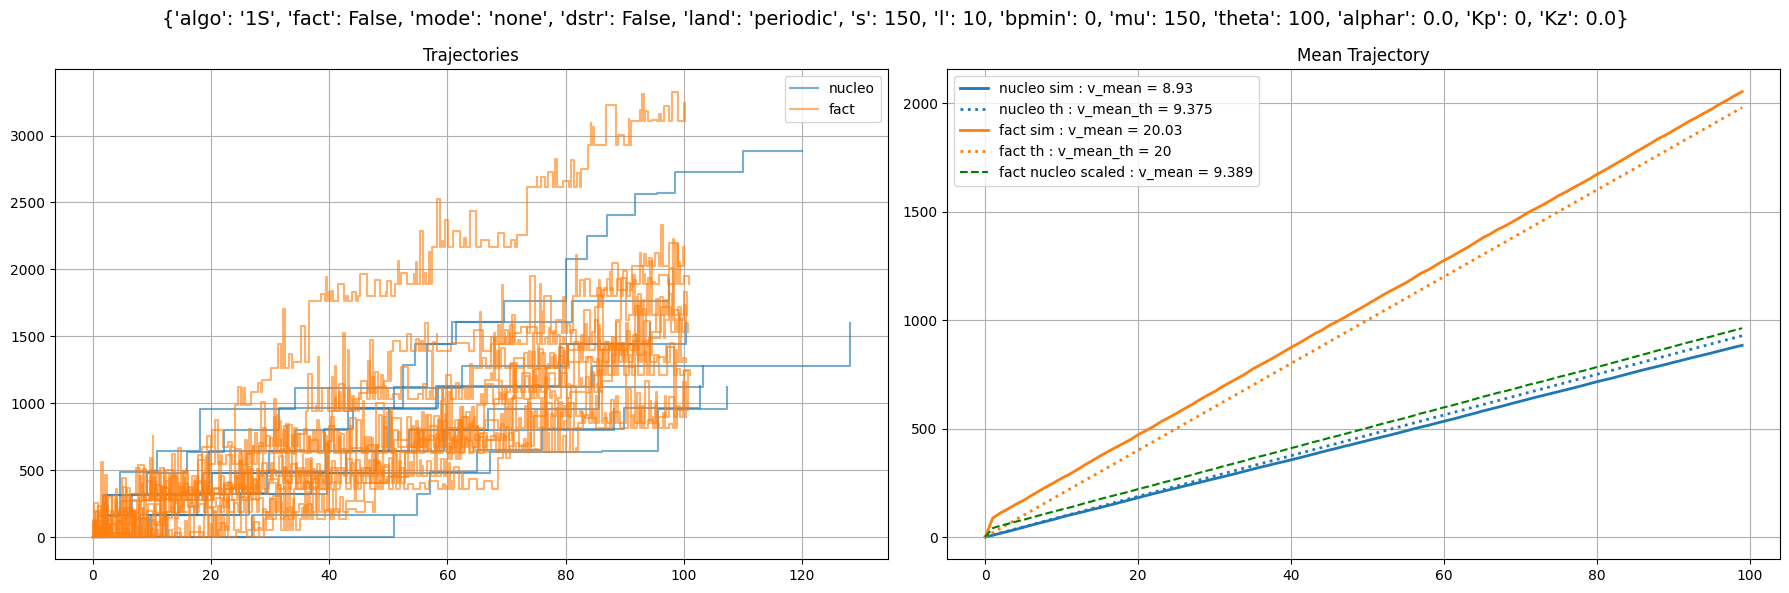

In [ ]:
# ── I.2 : DATA COMPARAISON ──────────────────────────────────────────────────────────────────────

# Comparing both approaches
# Getting adpated values
# Checking the validity of the second method


# ── PARAMS ──────────────────────────────────────────────────────────────────────

params_single_nucleo = {
    "algo"      : "1S",
    "fact"      : False,
    "mode"      : "none",
    "dstr"      : False, 
    "land"      : "periodic",
    "s"         : 150,
    "l"         : 10,
    "bpmin"     : 0,
    "mu"        : 150,
    "theta"     : 100,
    "alphar"    : 0.00,
    "Kp"        : FILTERS["Kp"],
    "Kz"        : FILTERS["Kz"],
}

params_fact = {
    **params_single_nucleo,
    "algo"      : "2S",
    "fact"      : True,
    "mode"      : "passfull",
    "s"         : 35,
    "l"         : 10,
}


# ── READING ──────────────────────────────────────────────────────────────────────

df_single_nucleo    = finding_one_parquet(root=root_nucleo, params=params_single_nucleo)
df_single_fact      = finding_one_parquet(root=root_fact, params=params_fact)

if df_single_nucleo.columns == df_single_fact.columns:
    print("\n# ──  Ready for study ── #")


# ── PLOT : Function ──────────────────────────────────────────────────────────────────────

def plot_df_main_info(dfs: list[tuple[pl.DataFrame, pl.DataFrame, str]], title: str = "") -> None:
    fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(18, 6))
    if title:
        fig.suptitle(title, fontsize=14)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for idx, (df, df_other, label) in enumerate(dfs):
        color = colors[idx % len(colors)]

        # Trajectories
        x1 = df["t_matrix"][0].to_numpy()
        y1 = df["x_matrix"][0].to_numpy()
        for i in range(10):
            ax1.plot(x1[i], y1[i], drawstyle="steps-mid", color=color,
                     alpha=0.6, label=label if i == 0 else None)

        # Data
        times        = df["times"][0].to_numpy()
        results_mean = df["results_mean"][0].to_numpy()
        v_mean       = df["v_mean"][0]
        v_mean_th    = df["v_mean_th"][0]
        y_th         = times * v_mean_th


        # Plot        
        ax2.plot(times, results_mean, color=color,
                 label=f"{label} sim : v_mean = {v_mean:.4g}", ls="-", lw=2)
        ax2.plot(times, y_th, color=color,
                 label=f"{label} th : v_mean_th = {v_mean_th:.4g}", ls=":", lw=2)

        # Scaling
        if "fact" in label:
            alphac   = df["alphac"][0]
            rcapt    = df["rcapt"][0]
            rrest    = df["rrest"][0]
            lF       = df["l"][0]
            sF       = df["s"][0]
            lN       = df_other["l"][0]
            sN       = df_other["s"][0]
            factor   = 1 / (1/rcapt + 1/rrest) * alphac * (lF / (lF + sF)) * ((sN + lN) / lN)
            y_scaled = results_mean / factor
            v_nucleo = v_mean / factor
            ax2.plot(times, y_scaled, color="g",
                     label=f"{label} nucleo scaled : v_mean = {v_nucleo:.4g}", ls="--")

    ax1.set_title("Trajectories")
    ax1.grid(True, which="both")
    ax1.legend()
    ax2.set_title(f"Mean Trajectory")
    ax2.grid(True, which="both")
    ax2.legend()
    plt.tight_layout()
    plt.show()


# ── PLOT : Call ──────────────────────────────────────────────────────────────────────

plot_df_main_info(
    dfs=[
        (df_single_nucleo, df_single_fact, "nucleo"),
        (df_single_fact, df_single_nucleo, "fact"),
    ],
    title=f"{params_single_nucleo}"
)

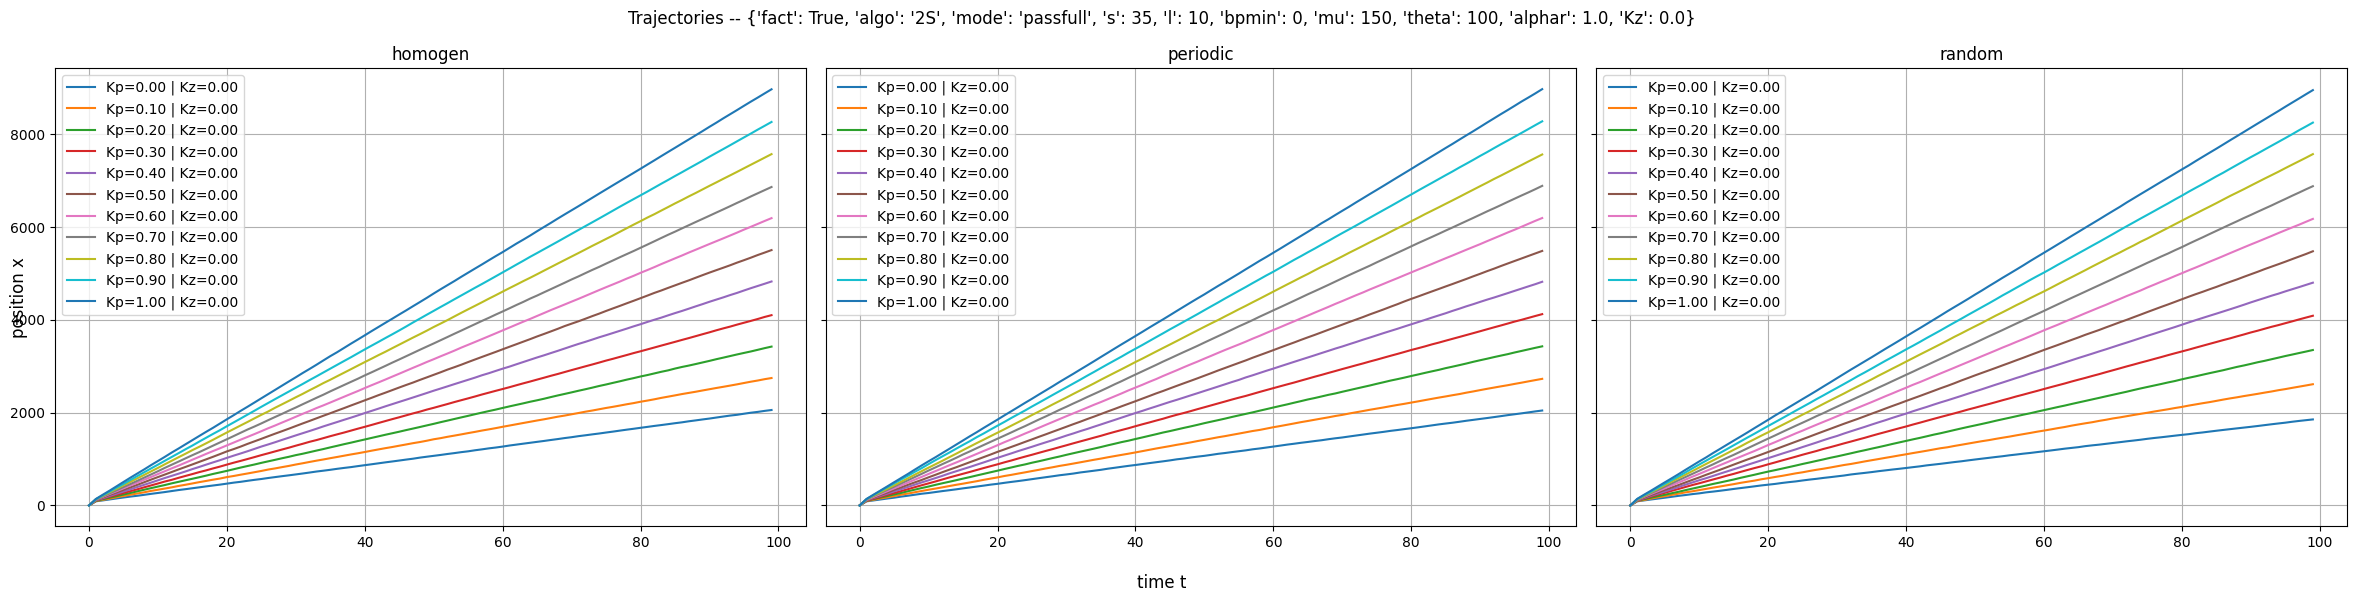

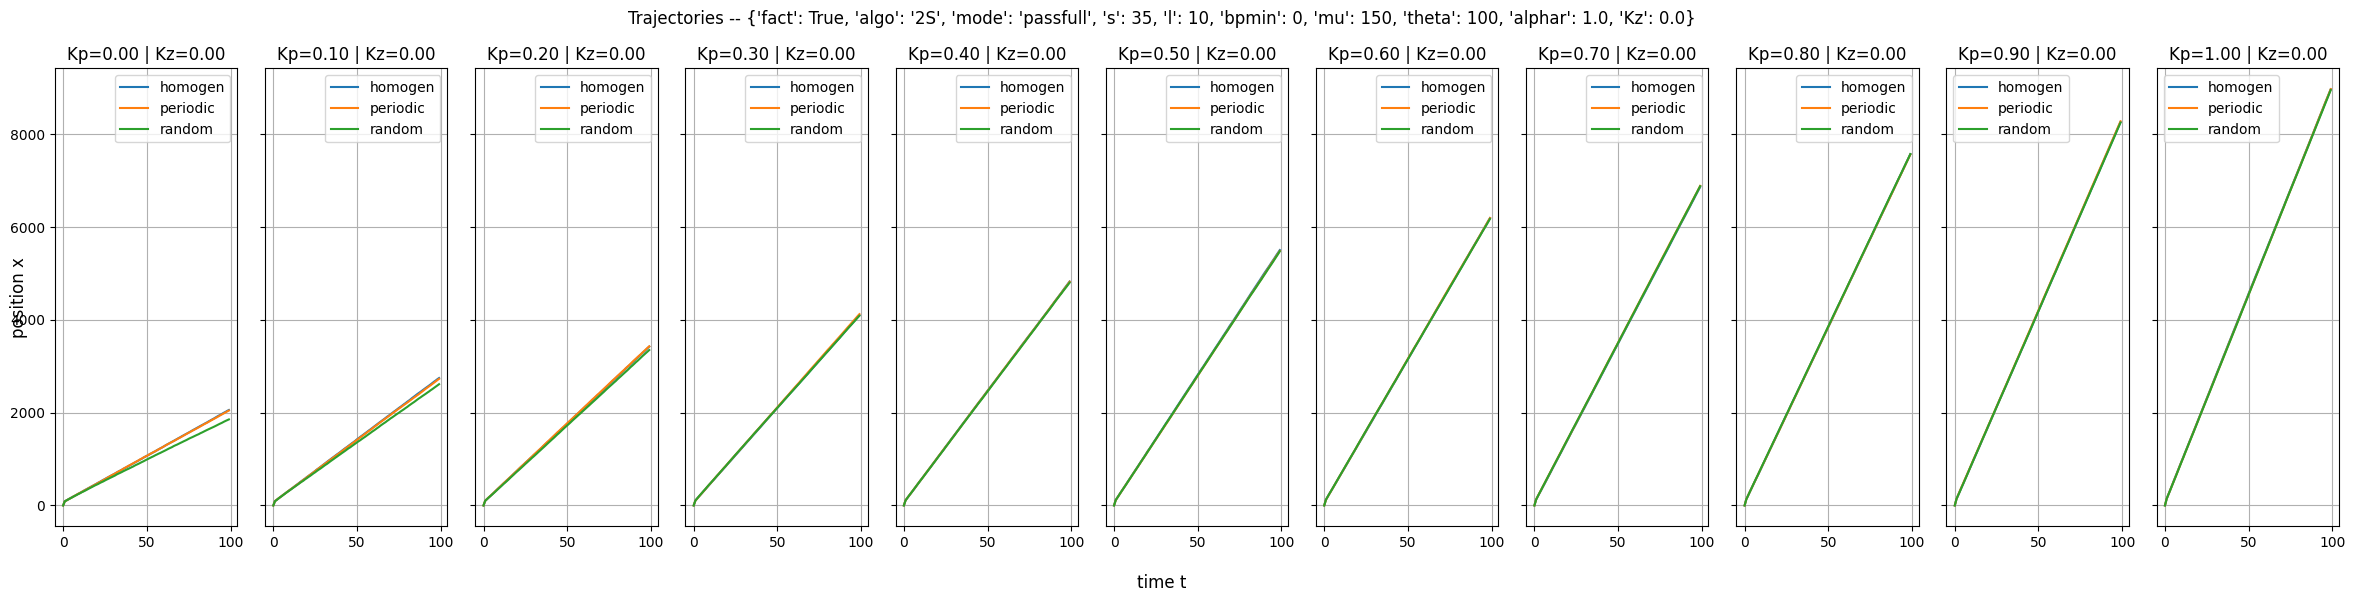

In [ ]:
# ── I.3 : DATA TRAJECTORIES ───────────────────────────────────────────────────────

# ── PLOT : Function ───────────────────────────────────────────────────────────
def plot_trajectories(
    df: pl.DataFrame,
    *,
    group_by: str,           # "land" ou "kp"
    params_fixed: dict = {},
):
    """
    group_by="land" → un axe par land, une courbe par Kp
    group_by="kp"   → un axe par Kp,   une courbe par land
    """
    assert group_by in ("land", "kp")

    lands     = sorted(df["land"].unique().to_list())
    Kp_values = sorted(df["Kp"].unique().to_list())
    Kz        = df["Kz"][0]

    axes_items  = lands     if group_by == "land" else Kp_values
    inner_items = Kp_values if group_by == "land" else lands

    fig, axes = plt.subplots(nrows=1, ncols=len(axes_items), figsize=(24, 6), sharey=True)
    fig.suptitle(f"Trajectories -- {params_fixed}")
    fig.supxlabel("time t")
    fig.supylabel("position x")

    for ax, ax_val in zip(axes, axes_items):
        ax.set_title(f"Kp={ax_val:.2f} | Kz={Kz:.2f}" if group_by == "kp" else ax_val)
        for inner_val in inner_items:
            land = ax_val    if group_by == "land" else inner_val
            Kp   = inner_val if group_by == "land" else ax_val
            df_sub = df.filter((pl.col("land") == land) & (pl.col("Kp") == Kp))
            if df_sub.is_empty():
                continue
            times        = df_sub["times"][0].to_numpy()
            results_mean = df_sub["results_mean"][0].to_numpy()
            v_mean       = df_sub["v_mean"][0]
            label = f"Kp={Kp:.2f} | Kz={Kz:.2f}" if group_by == "land" \
                    else f"{land}"
            ax.plot(times, results_mean, label=label)
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

# ── PLOT : Call ───────────────────────────────────────────────────────────────
params_fixed = {
    "fact"  : True,
    "algo"  : "2S",
    "mode"  : "passfull",
    "s"     : 35,
    "l"     : 10,
    "bpmin" : 0,
    "mu"    : 150,
    "theta" : 100,
    "alphar": 1.0,
    "Kz"    : 0.00
}

df_study = df_all.filter(pl.all_horizontal(pl.col(k) == v for k, v in params_fixed.items()))

plot_trajectories(df_study, group_by="land", params_fixed=params_fixed)
plot_trajectories(df_study, group_by="kp",   params_fixed=params_fixed)

[20.00349386 26.95046943 34.00406532 40.95478961 48.02007475 54.91655485
 61.6684709  69.02365914 75.67844857 82.92831875 89.75984955]
[20.01329122 28.37598487 35.86712259 43.31584611 50.55442776 57.23410018
 64.24528318 70.6147054  77.19852128 83.50149674 89.81716579]
[17.82247693 27.3445738  35.39186598 43.00284483 50.31631547 56.97226009
 63.94776312 70.37677974 77.1785206  83.43972556 89.74161788]


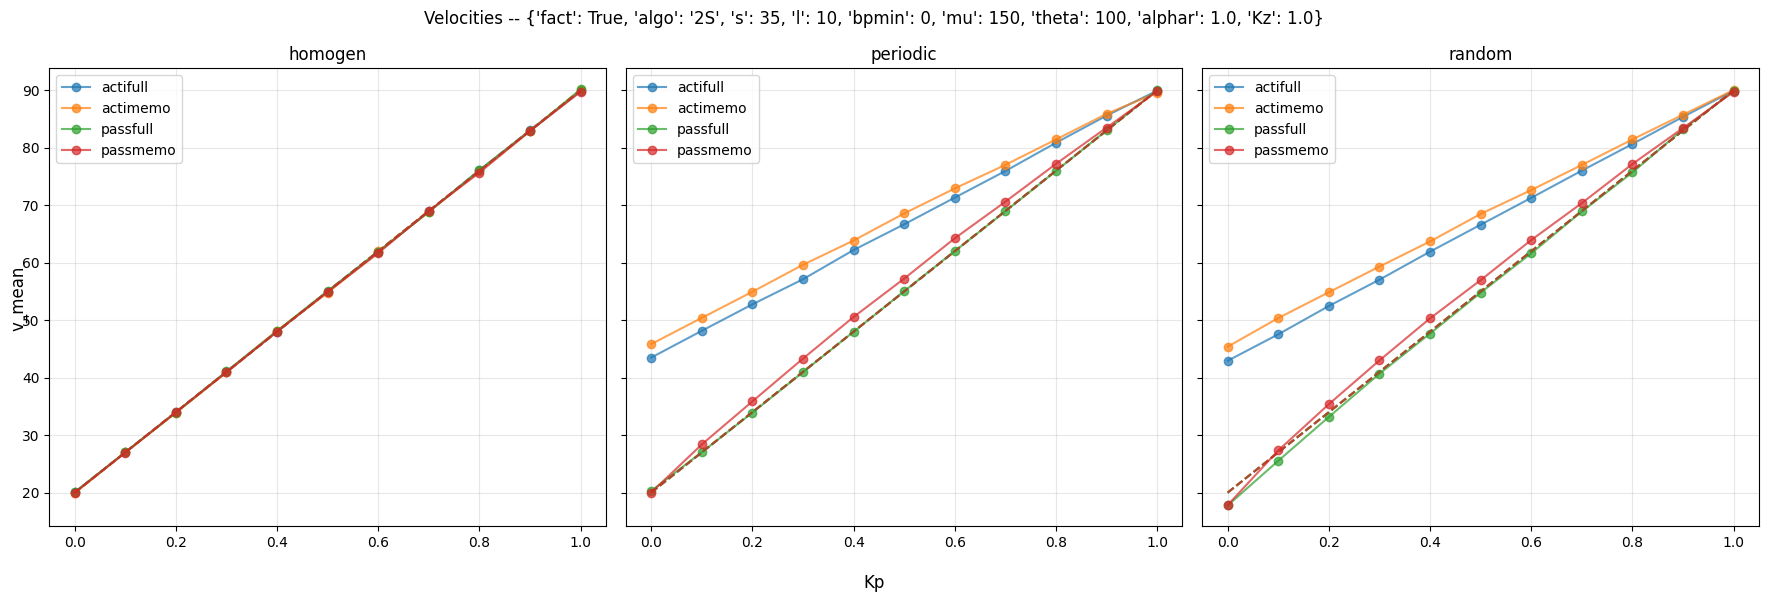

[0.9521393  0.96317924 0.97489045 0.99747719 0.97709098 0.99152706
 0.99045316 0.98879604 1.00077371 0.99074376 0.99281284]
[0.97074141 0.95856742 0.98784971 0.98886878 0.98123998 0.997668
 0.99134396 0.99584293 0.9900573  0.9936979  0.99421163]
[0.92732907 0.98350484 0.96944685 0.99142802 0.99595816 0.99211981
 0.99735578 0.99005074 0.99495191 1.00068387 1.00184119]


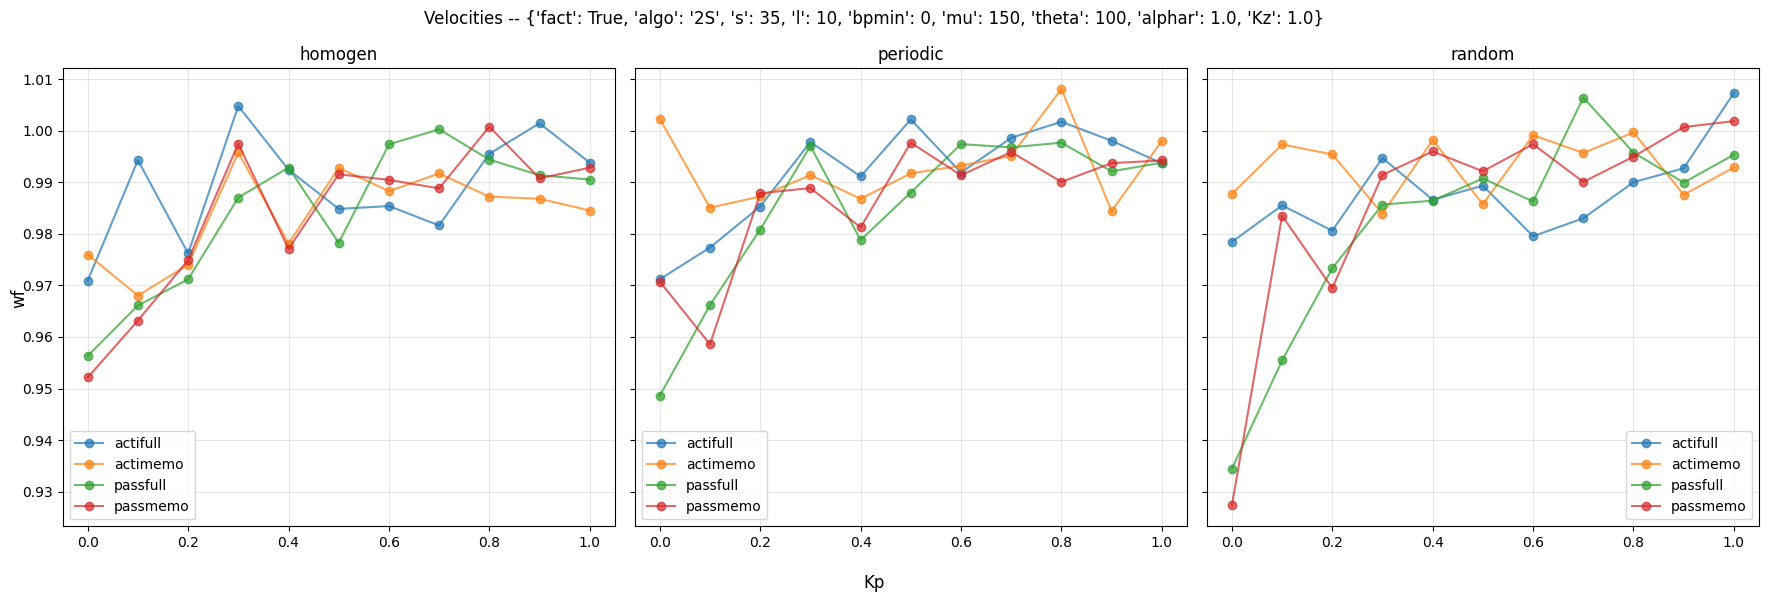

In [ ]:
# ── I.4 : DATA VELOCITIES ─────────────────────────────────────────────────────

# ── PLOT : Function ───────────────────────────────────────────────────────────
def plot_velocities(
    df: pl.DataFrame,
    *,
    y_col: str = "v_mean",
    y_th_col: str | None = None,
    params_fixed: dict = {},
):
    lands = sorted(df["land"].unique().to_list())
    modes = sorted(df["mode"].unique().to_list())

    fig, axes = plt.subplots(ncols=len(lands), figsize=(6 * len(lands), 6), sharey=True)
    if len(lands) == 1:
        axes = [axes]
    fig.suptitle(f"Velocities -- {params_fixed}")
    fig.supxlabel("Kp")
    fig.supylabel(y_col)

    for ax, land in zip(axes, lands):
        ax.set_title(land)
        for mode in modes:
            df_sub = df.filter((pl.col("land") == land) & (pl.col("mode") == mode))
            if df_sub.is_empty():
                continue
            x = df_sub["Kp"].to_numpy()
            y = df_sub[y_col].to_numpy()
            line, = ax.plot(x, y, marker="o", label=mode, alpha=0.7)
            if y_th_col is not None:
                ax.plot(x, df_sub[y_th_col].to_numpy(),
                        linestyle="--", color=line.get_color(), alpha=0.7)
        ax.grid(True, alpha=0.3)
        ax.legend()

        print(y)

    plt.tight_layout()
    plt.show()

# ── PLOT : Call ───────────────────────────────────────────────────────────────
params_fixed = {
    "fact"  : True,
    "algo"  : "2S",
    # "mode"  : "passfull",
    "s"     : 35,
    "l"     : 10,
    "bpmin" : 0,
    "mu"    : 150,
    "theta" : 100,
    "alphar": 1.0,
    "Kz"    : 1.00
}

df_study = df_all.filter(pl.all_horizontal(pl.col(k) == v for k, v in params_fixed.items()))

plot_velocities(df_study, y_col="v_mean", y_th_col="v_mean_th", params_fixed=params_fixed)
plot_velocities(df_study, y_col="wf", y_th_col=None, params_fixed=params_fixed)

Problem in normalizing.
[0.9977173  1.34421266 1.69602593 2.04270826 2.39510456 2.73908134
 3.07584769 3.44270353 3.77462547 4.13622835 4.47696565]
[1.00152671 1.42002165 1.79490125 2.16765831 2.52989922 2.86417059
 3.21503178 3.53377728 3.8632517  4.178672   4.49472752]
[0.9927606  1.52316739 1.97142352 2.39537582 2.80275609 3.17351037
 3.56206493 3.9201787  4.29905423 4.64782043 4.99885303]


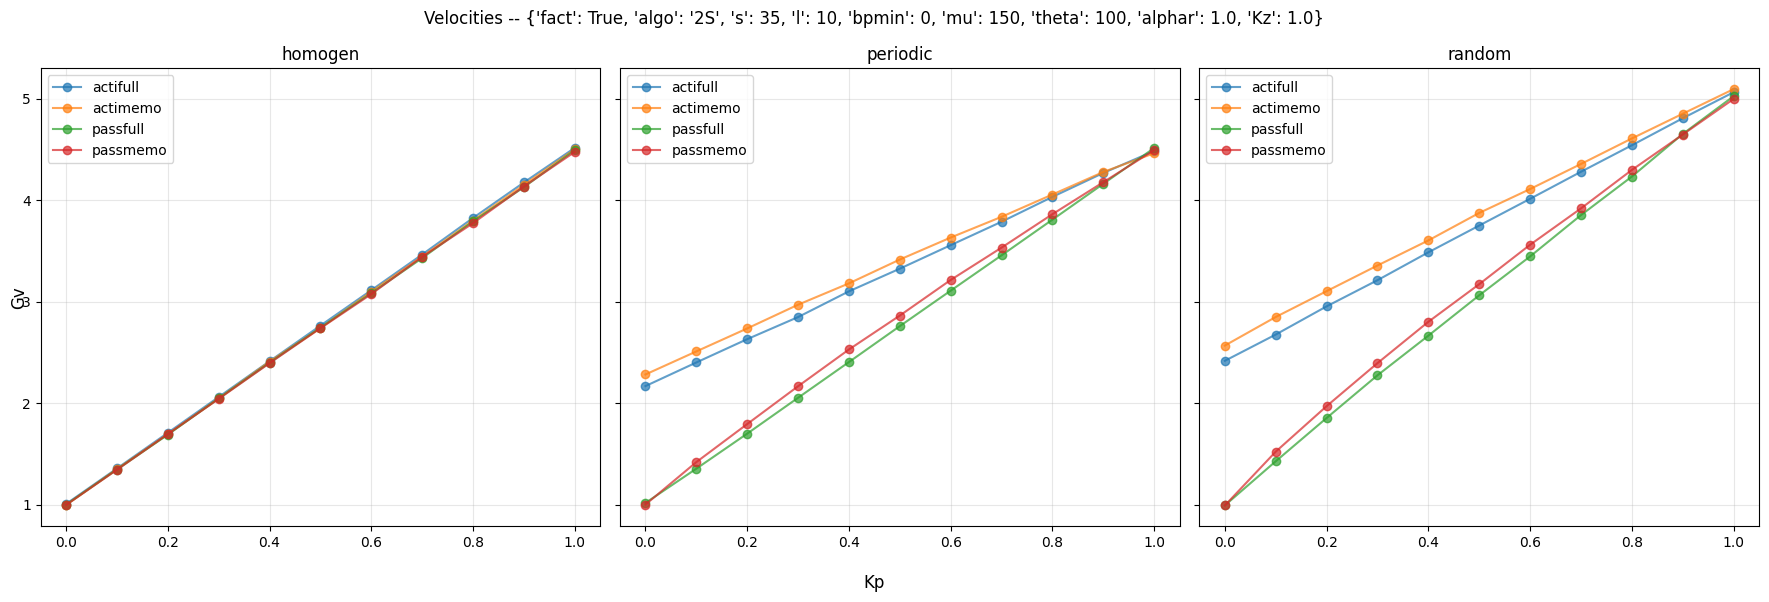

[0.97583715 0.98715187 0.99915456 1.02230345 1.00140985 1.01620524
 1.01510461 1.01340624 1.02568203 1.01540244 1.01752301]
[1.0050409  0.99243676 1.02275369 1.02380877 1.01591042 1.0329189
 1.0263714  1.03102934 1.02503928 1.02880852 1.0293404 ]
[0.98242614 1.04193958 1.02704634 1.05033351 1.05513281 1.05106641
 1.05661347 1.0488744  1.05406677 1.06013929 1.06136539]


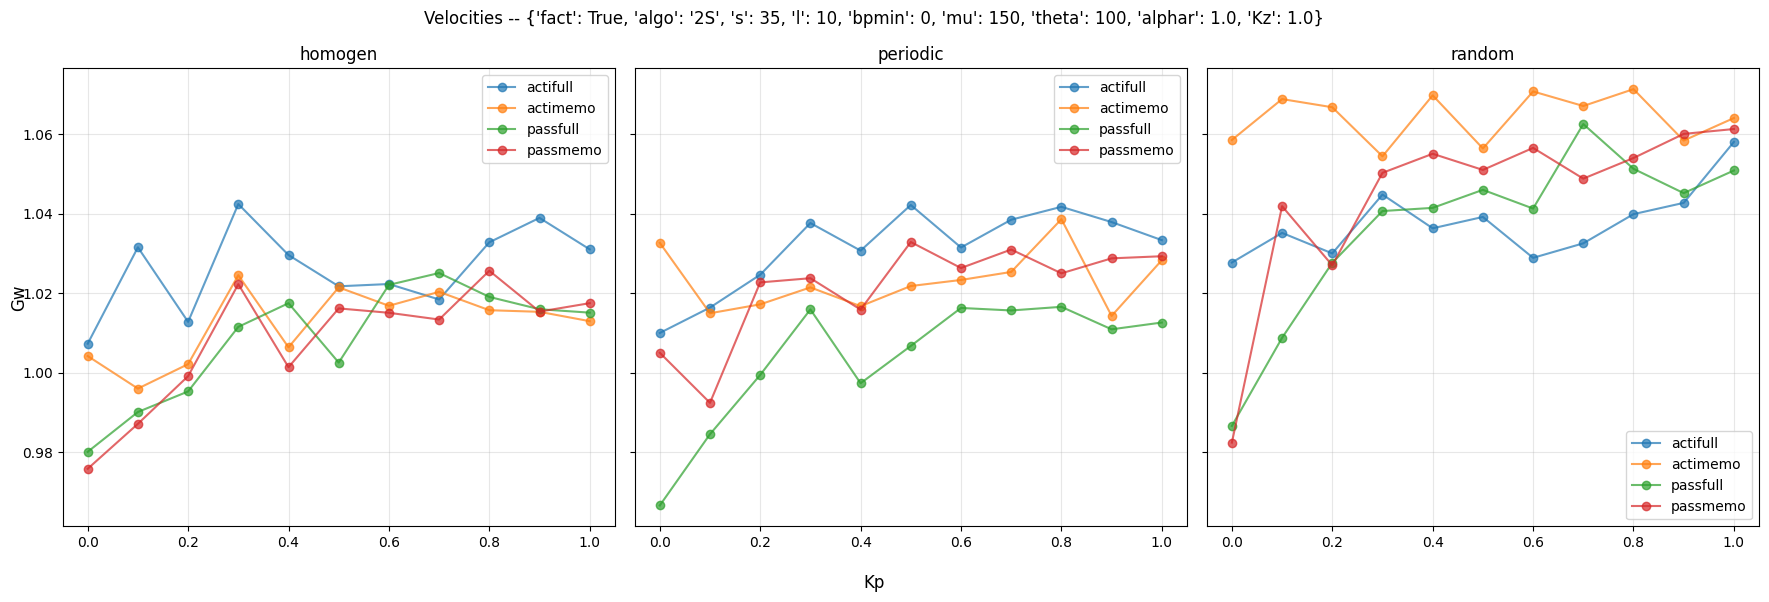

In [ ]:
# ── II.1 : DATA GAINS ──────────────────────────────────────────────────────────────────────

# Carefull with the way of making the gains
# Playing on two different key concepts :
# Dividing by Kz = 0.00 / 1.00
# Comparing to homogen or same land

# ── ADDING GAINS ─────────────────────────────────────────────────────────────
ALL_KEYS = ["algo", "fact", "mode", "dstr", "land", "s", "l", "bpmin", "mu", "theta", "alphar", "Kp", "Kz"]
GAINS    = [("v_mean", "Gv"), ("wf", "Gw")]


def add_gain_columns(
    df: pl.DataFrame,
    all_keys: list[str],
    ref_filters: dict[str, object],
    cols_to_normalize: list[tuple[str, str]],
) -> pl.DataFrame:
    """
    Calcule des gains normalisés par rapport à une ligne de référence.

    Paramètres
    ----------
    all_keys          : colonnes identifiant un scénario unique.
    ref_filters       : conditions définissant la référence (ex: {"Kp": 0, "land": "homogen"}).
    cols_to_normalize : liste de (colonne_source, nom_du_gain).
    """
    join_keys = [k for k in all_keys if k not in ref_filters]

    ref_mask = pl.all_horizontal(pl.col(col) == val for col, val in ref_filters.items())
    df_ref = (
        df.filter(ref_mask)
        .group_by(join_keys)
        .agg(pl.col(src).mean().alias(f"_ref_{alias}") for src, alias in cols_to_normalize)
    )

    ref_cols = [f"_ref_{alias}" for _, alias in cols_to_normalize]
    return (
        df.join(df_ref, on=join_keys, how="left")
        .with_columns((pl.col(src) / pl.col(f"_ref_{alias}")).alias(alias) for src, alias in cols_to_normalize)
        .drop(ref_cols)
    )

# Cas 1 : référence Kp==0 & Kz ==0 - land==homogen, partagée entre tous les scénarios
df_1 = add_gain_columns(
    df_all,
    all_keys          = ALL_KEYS,
    ref_filters       = {**FILTERS, "land": "homogen"},
    cols_to_normalize = GAINS,
)

# Cas 2 : référence Kp==0  & Kz ==0 - chaque land garde sa propre référence
df_2 = add_gain_columns(
    df_all,
    all_keys          = ALL_KEYS,
    ref_filters       = FILTERS,
    cols_to_normalize = GAINS,
)


# ── CHOOSING ──────────────────────────────────────────────────────────────────
df_study = df_2
# print(df_study)


# ── CHECKING ──────────────────────────────────────────────────────────────────
df_check = (
    df_study
    .filter(
        (pl.col("s")     == 35  ) &
        (pl.col("mu")    == 150 ) &
        (pl.col("theta") == 100 ) &
        (pl.col("Kp")    == 0.00)
    )
    .select(["land", "mode", "l", "Gv", "Gw"])
)

if not np.allclose(df_check["Gv"].to_numpy(), 1.0) or not np.allclose(df_check["Gw"].to_numpy(), 1.0):
    print("Problem in normalizing.")


# ── PLOT : Call ───────────────────────────────────────────────────────────────
params_fixed = {
    "fact"  : True,
    "algo"  : "2S",
    "s"     : 35,
    "l"     : 10,
    "bpmin" : 0,
    "mu"    : 150,
    "theta" : 100,
    "alphar": 1.0,
    "Kz"    : 1.00
}

df_work = df_study.filter(pl.all_horizontal(pl.col(k) == v for k, v in params_fixed.items()))

plot_velocities(df_work, y_col="Gv", y_th_col=None, params_fixed=params_fixed)
plot_velocities(df_work, y_col="Gw", y_th_col=None, params_fixed=params_fixed)

[0.9977173  1.34421266 1.69602593 2.04270826 2.39510456 2.73908134
 3.07584769 3.44270353 3.77462547 4.13622835 4.47696565]
[1.00152671 1.42002165 1.79490125 2.16765831 2.52989922 2.86417059
 3.21503178 3.53377728 3.8632517  4.178672   4.49472752]
[0.9927606  1.52316739 1.97142352 2.39537582 2.80275609 3.17351037
 3.56206493 3.9201787  4.29905423 4.64782043 4.99885303]


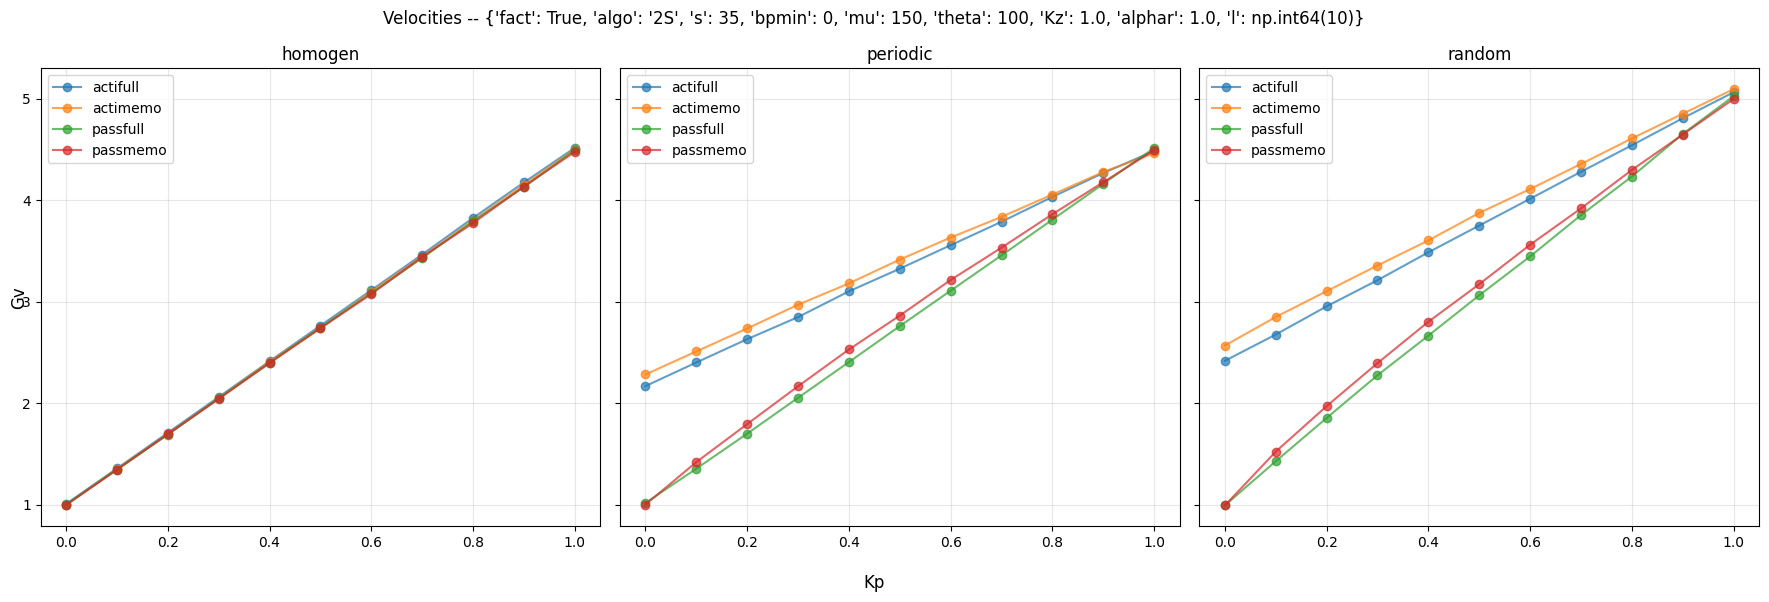

[1.00787135 1.10814618 1.21251293 1.31135909 1.40630778 1.51057139
 1.61411952 1.7056606  1.8087009  1.91560969 2.01445888]
[0.99831004 1.10636905 1.21963193 1.32003729 1.41923259 1.5232567
 1.61941172 1.70714775 1.80770012 1.90615445 1.99714156]
[1.00434458 1.14678711 1.28157108 1.40920848 1.52530334 1.6428157
 1.75020213 1.85831721 1.95498234 2.06405512 2.17031286]


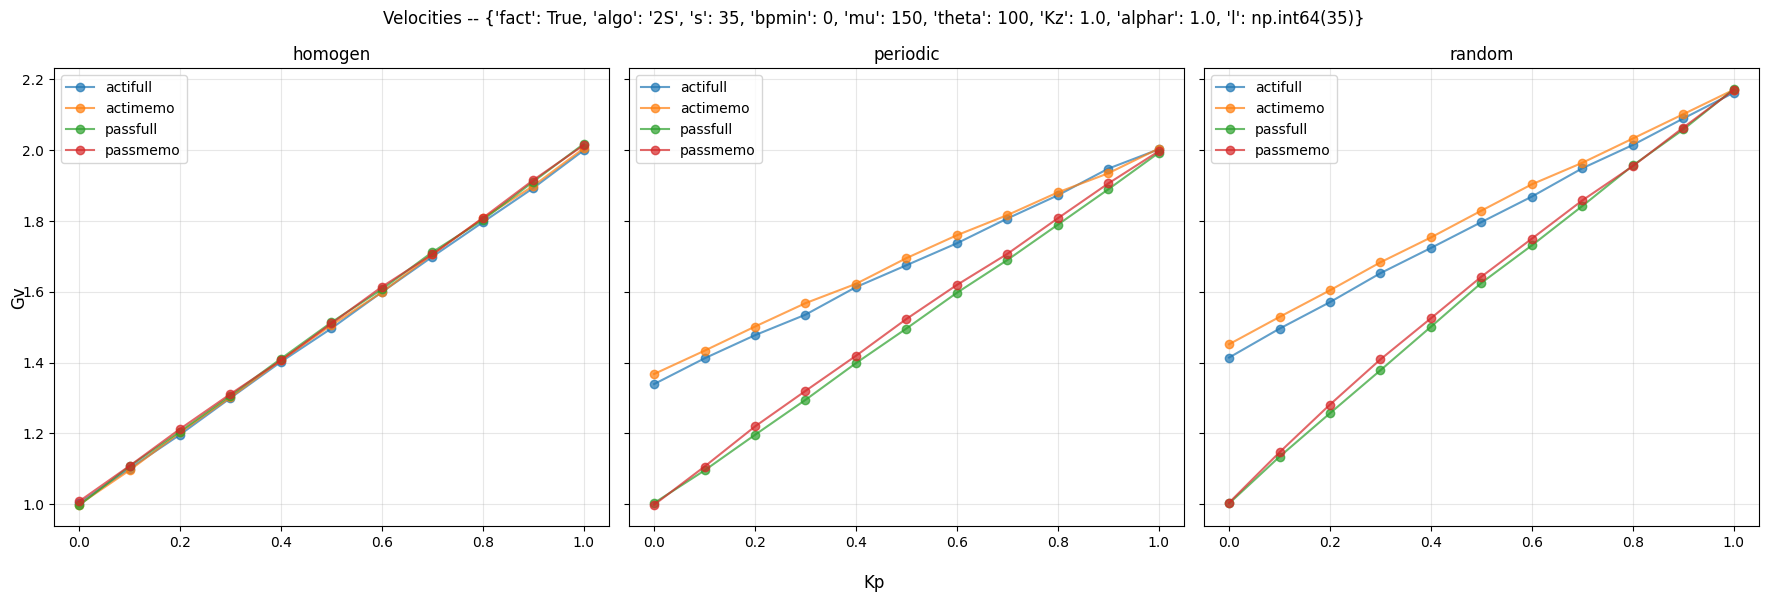

[0.99452638 1.0288585  1.07207635 1.10401591 1.13671622 1.16849138
 1.20646601 1.24080393 1.27665893 1.30820295 1.3458133 ]
[0.99412626 1.03310533 1.06907715 1.1069444  1.14586429 1.18326252
 1.22016151 1.24674988 1.2832327  1.31150858 1.34747267]
[1.00207365 1.05656931 1.10510365 1.15053005 1.19284526 1.22909192
 1.26804663 1.30746644 1.34545274 1.37564223 1.41539965]


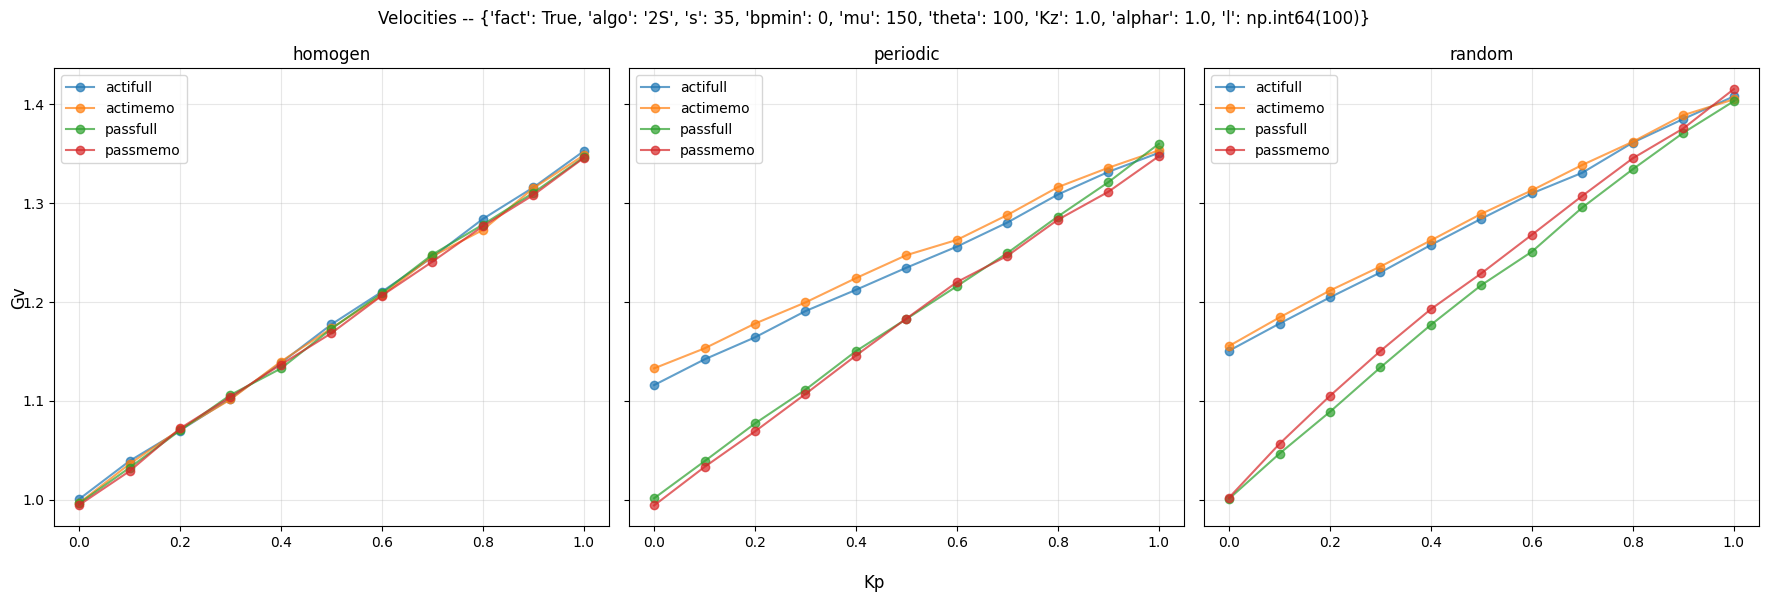

In [ ]:
# ── II.2 : GAINS COMPARAISON ──────────────────────────────────────────────────

# ── PLOT : Call ───────────────────────────────────────────────────────────────
params_fixed = {
    "fact"  : True,
    "algo"  : "2S",
    "s"     : 35,
    "bpmin" : 0,
    "mu"    : 150,
    "theta" : 100,
    "Kz"    : 1.00,
    "alphar": 1.0,
}

for l in np.unique(df_study["l"].to_numpy()):
    pf = {**params_fixed, "l": l}
    df_work = (
        df_study
        .filter(pl.all_horizontal(pl.col(k) == v for k, v in pf.items()))
    )
    plot_velocities(df_work, y_col="Gv", params_fixed=pf)


In [ ]:
# ── III.1 : HEATMAPS FUNCTION ──────────────────────────────────────────────────────────────────────

df_heatmaps = df_study.clone()

def plot_single_heatmap(
    df: pl.DataFrame,
    land: str,
    l: int,
    value: str,
    ax,
    log_plot: bool = False,
    cmap: str = "plasma",
):
    """
    Plot a heatmap of `value` as a function of alphar (x) and K (y)
    for a given land and l.
    """
    # 1) Filtrage (alphar = 0 exclu)
    df_heat = (
        df.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l) &
            (pl.col("alphar") > 0)
        )
        .select(["alphar", "Kp", value])
        .sort(["Kp", "alphar"])
    )

    if df_heat.height == 0:
        ax.set_title(f"{land} -- l={l}\n(no data)")
        return None

    # 2) Pivot 100% Polars → pas besoin de pandas
    pivot_pl = (
        df_heat
        .group_by(["Kp", "alphar"])
        .agg(pl.col(value).mean())
        .sort(["Kp", "alphar"])
        .pivot(on="alphar", index="Kp", values=value)
        .sort("Kp")
    )

    # Extraction des axes et de la grille
    Y = pivot_pl["Kp"].to_numpy()                          # lignes  (K)
    X = np.array(                                          # colonnes (alphar)
        sorted(float(c) for c in pivot_pl.columns if c != "Kp")
    )
    col_order = [str(x) for x in X]                       # ordre cohérent
    Z2D = pivot_pl.select(col_order).to_numpy().astype(float)

    X_grid, Y_grid = np.meshgrid(X, Y)

    # # 3) Scale (lin / log)
    # if log_plot:
    #     Z2D = np.log2(Z2D)
    #     vmin, vmax = -2, 2
    # else:
    #     if value == "v_mean":
    #         vmin, vmax = 0, 100
    #     elif value == "wf":
    #         vmin, vmax = 0, 50
    #     elif value == "Gv":
    #         vmin, vmax = 0, 2
    #     elif value =="Gw":
    #         vmin, vmax = 0, 2
    #     else:
    #         vmin, vmax = None, None

    # 4) Plot
    c = ax.pcolormesh(
        X_grid, Y_grid, Z2D,
        cmap=cmap,
        shading="auto",
        # vmin=vmin,
        # vmax=vmax,
    )
    ax.set_title(f"{land} -- l={l}")
    ax.set_xlabel(r"$\alpha_r$")
    ax.set_ylabel(r"$K_{p} = \frac{k_B}{k_B + k_U}$")

    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    return c


def plot_heatmaps(df_all: pl.DataFrame, value: str, cmap: str = "plasma"):
    """Trace les heatmaps pour toutes les combinaisons (land, l)."""
    lands = sorted(df_all["land"].unique().to_list())
    ls = sorted(df_all["l"].unique().to_list())

    n_rows = len(lands)
    n_cols = len(ls)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        constrained_layout=True,
    )
    axes_2d = np.array(axes).reshape(n_rows, n_cols)
    fig.suptitle(value)

    last_c = None
    for i, land in enumerate(lands):
        for j, l in enumerate(ls):
            c = plot_single_heatmap(df_all, land, l, value, axes_2d[i, j], cmap=cmap)
            if c is not None:
                last_c = c

    if last_c is not None:
        fig.colorbar(last_c, ax=axes_2d.ravel().tolist(), orientation='vertical', label=value)

    plt.show()

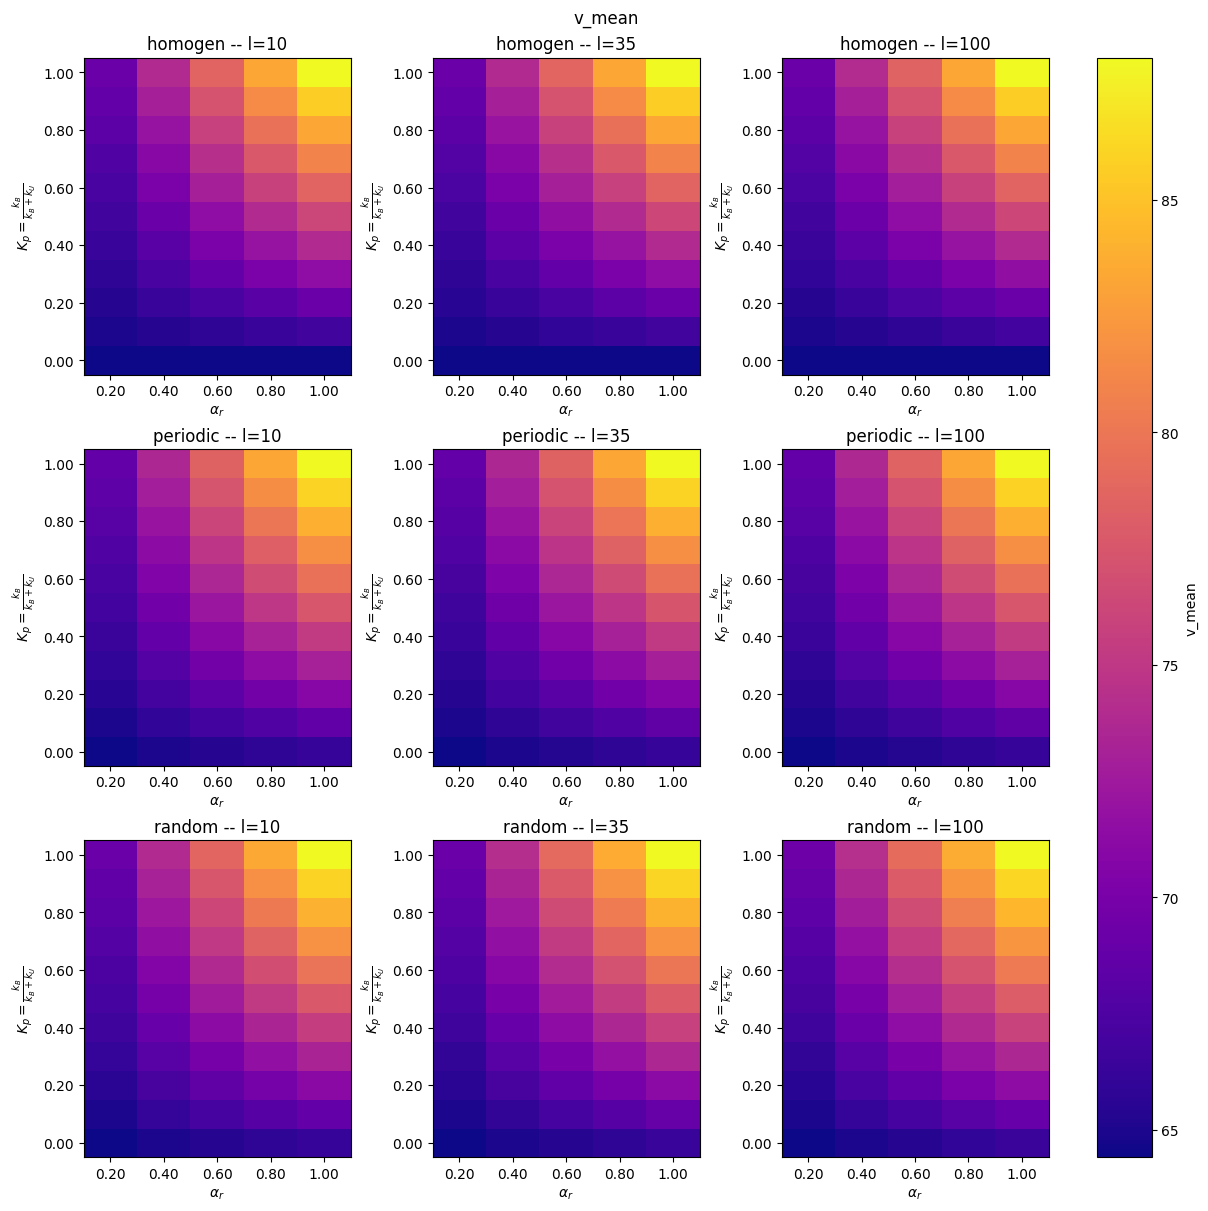

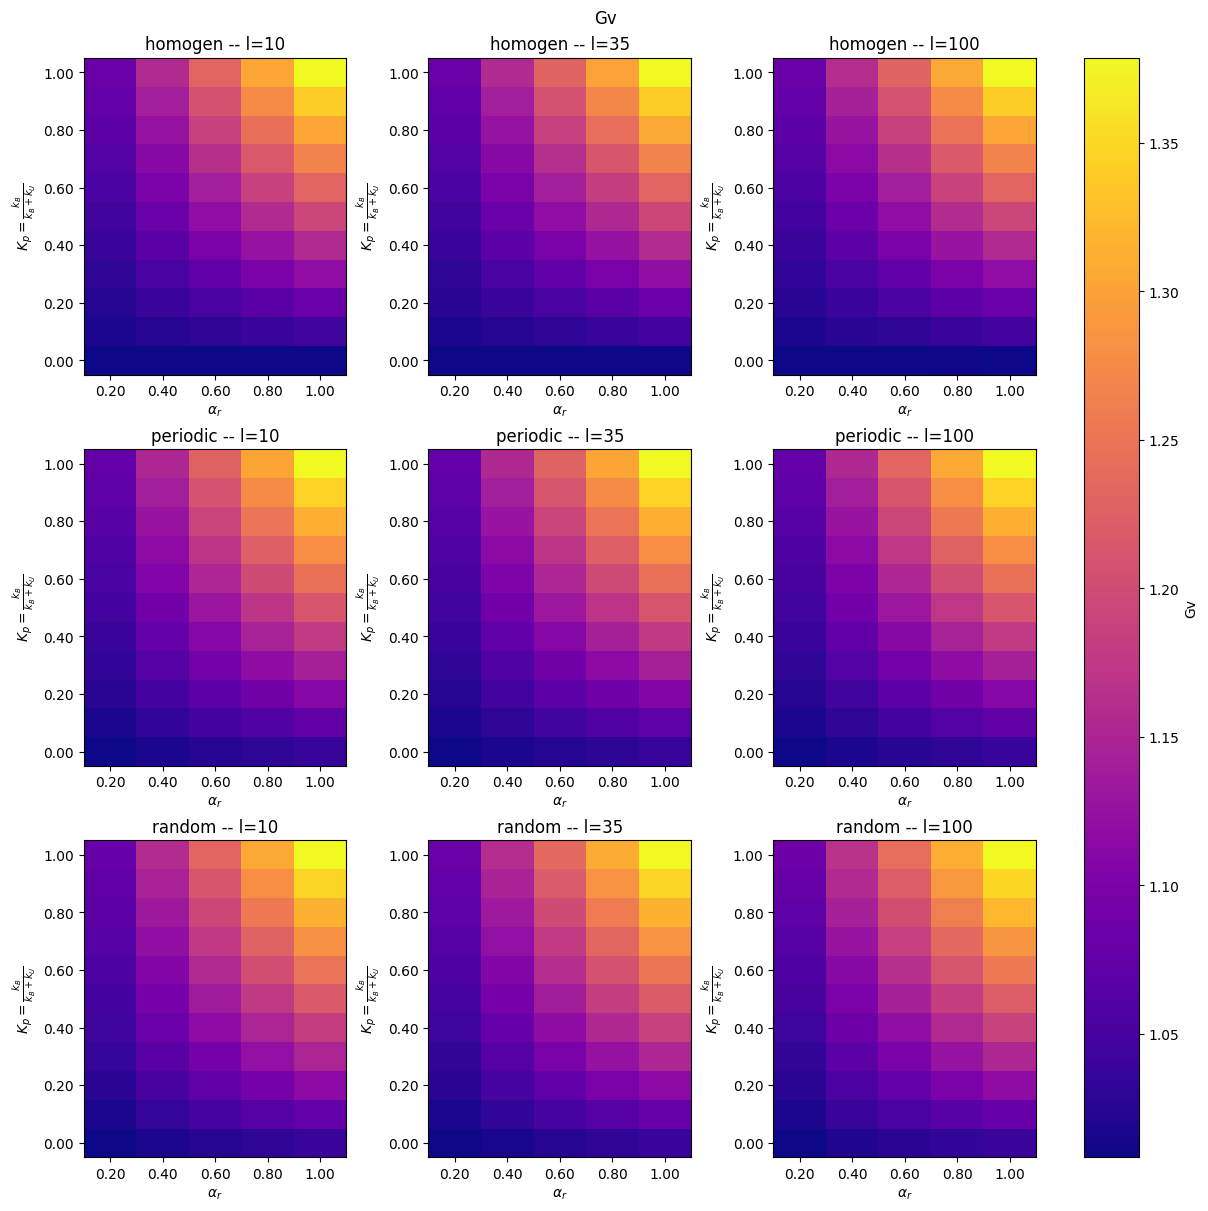

In [ ]:
# ── III.2 : HEATMAPS CALLS SPEEDS ──────────────────────────────────────────────────────────────────────
plot_heatmaps(df_heatmaps, "v_mean")
plot_heatmaps(df_heatmaps, "Gv")

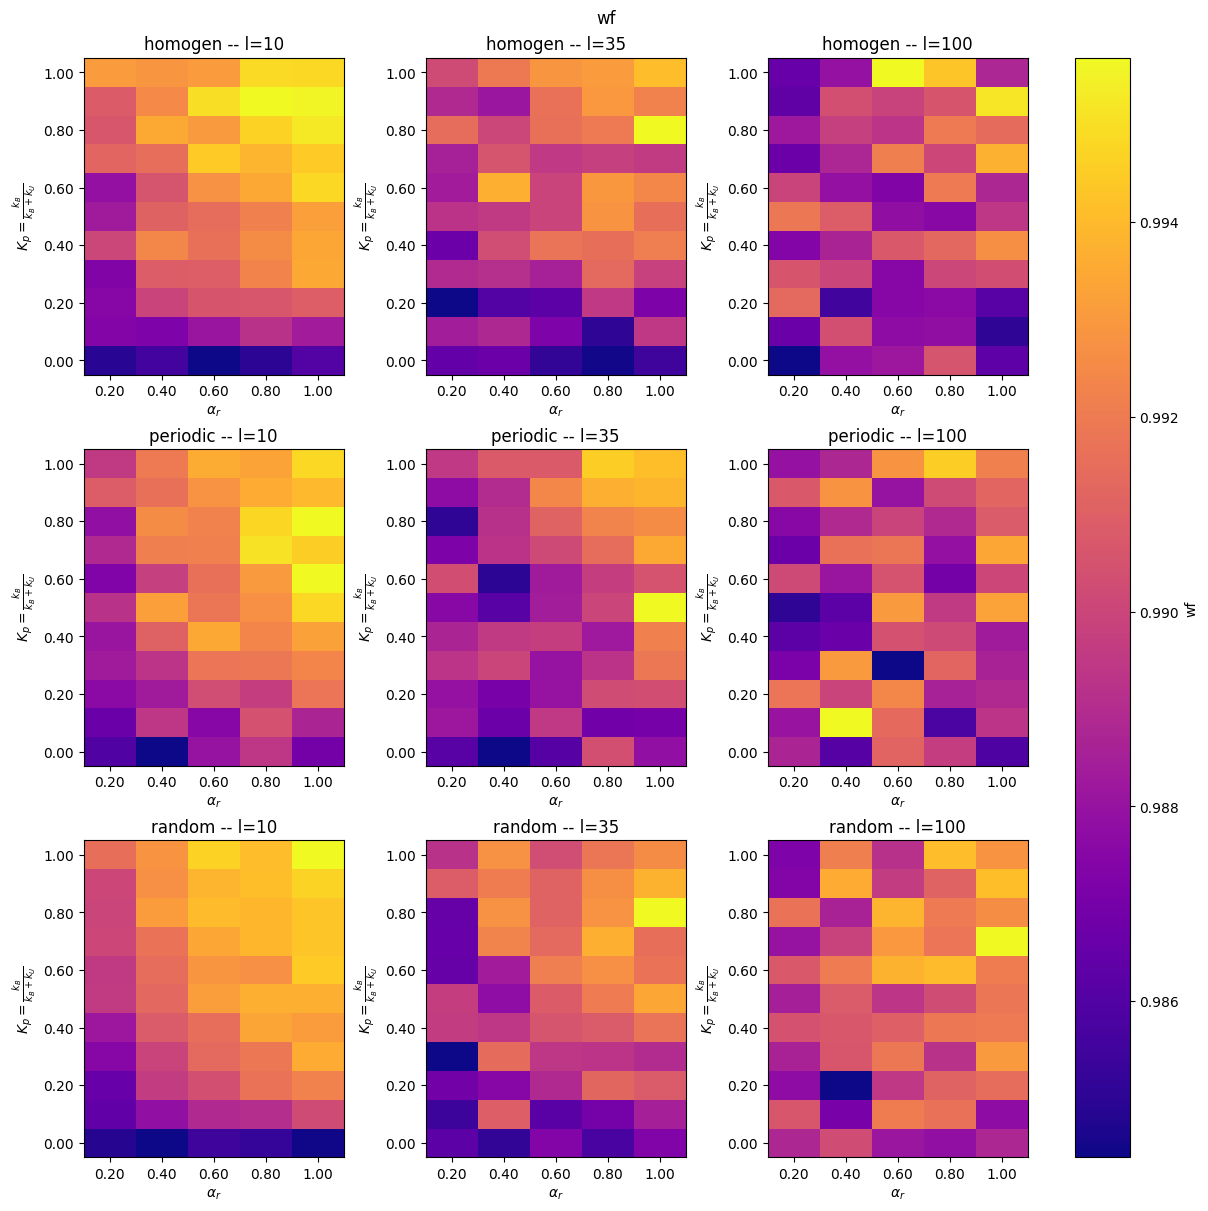

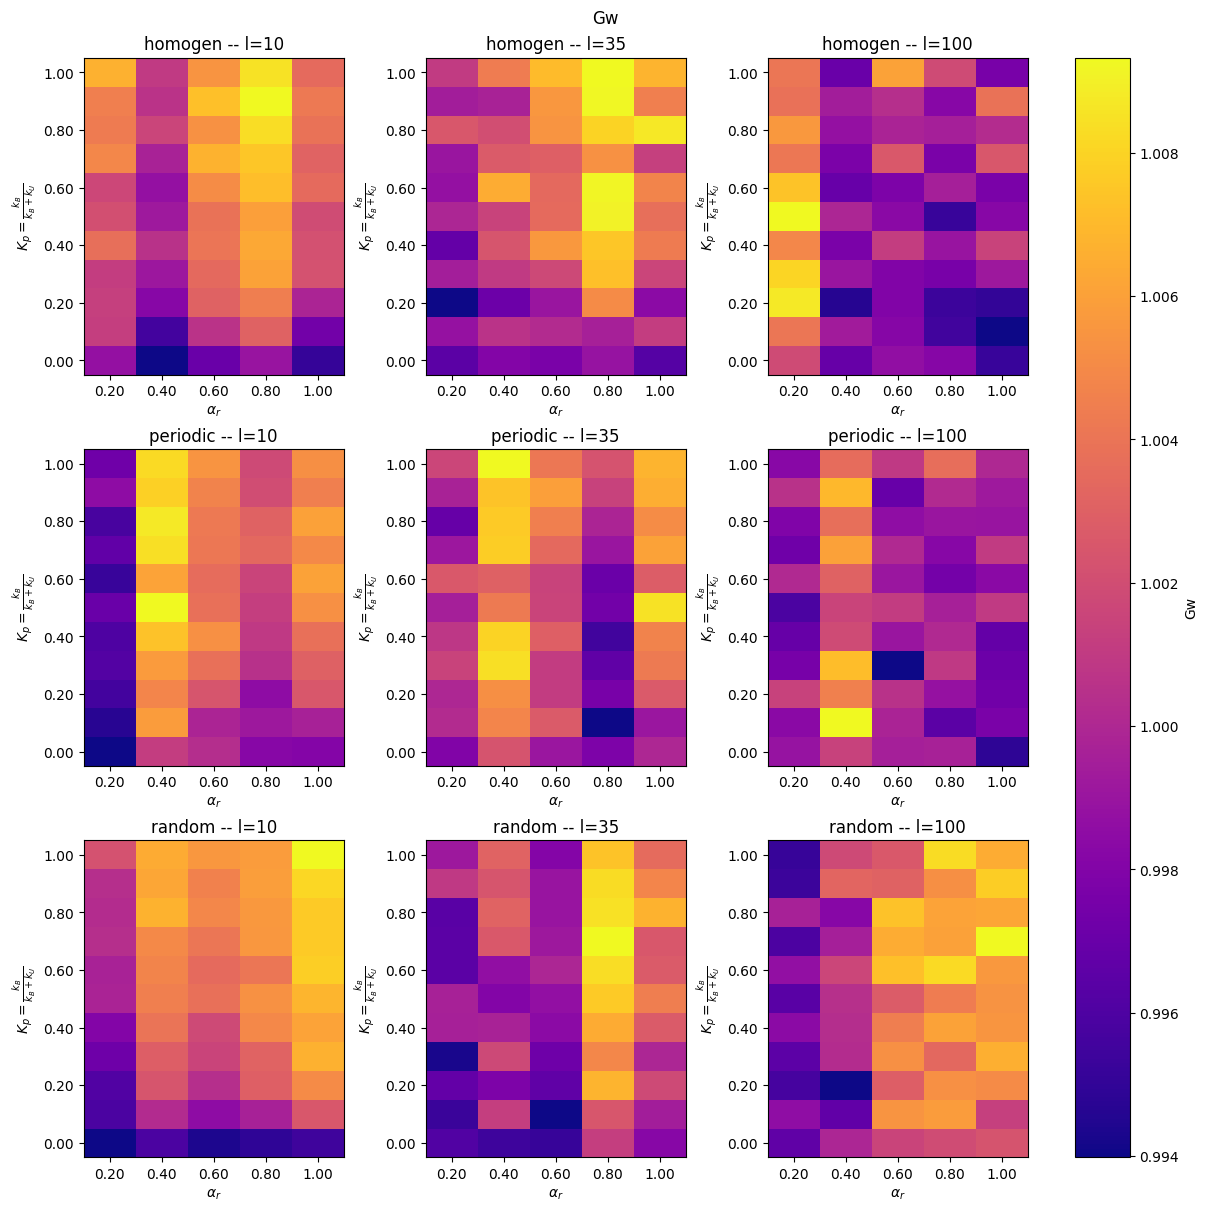

In [ ]:
# ── III.2 : HEATMAPS CALLS EXPONANT ──────────────────────────────────────────────────────────────────────
plot_heatmaps(df_heatmaps, "wf")
plot_heatmaps(df_heatmaps, "Gw")

# .